# Phase 2 — Evidence-sharing recommender (operationalisation 1)

First aided-regime experiment, implementing §3's **operationalisation 1**: the recommender is a distinguished agent with a directed edge to every user, sharing one labeled draw from the *true* bandit per agent per step; agents fold each shared observation into the labeled arm's Beta posterior by the ordinary conjugate update (`EvidenceSharingRecommender` in [`model/recommender.py`](../model/recommender.py)). The latent state $Z \in \{G, F\}$ with $P(Z = G) = 0.99$ acts on the data stream in two variants: **`state_arm`** ($G$: samples and truthfully labels the better arm $A$; $F$: the worse arm $B$ — honest data about the wrong theory) and **`confused`** (samples both arms in alternation; $G$ labels correctly, $F$ swaps the two theories' identities).

Three questions, one section each:

1. **Individual discovery by state.** $\hat q_{\text{gap}}$ under forced $Z = G$ and $Z = F$ for both variants at the §2 operating point ($\Delta = 0.01$, $\delta = \Delta/2$, flat prior), plus the `per_share` mixture control.
2. **Horizon dependence of the confused variant.** Its $F$-state drives every posterior gap toward a common negative value, so $q_F \to 0$ — but only once the shared stream's sampling noise falls below the gap, i.e. on horizons $T \gtrsim 1/\Delta^2$. We trace $\hat q(T)$.
3. **The community headline.** At $\Delta = 0.1$ the separation completes within $T = 3000$, so the full effect is demonstrable cheaply: the aided *individual* improves while the aided *community* falls to $\approx P(Z = G) = 0.99$, strictly below the unaided $\approx 1$ — and the `per_share` control (same marginal stream, $Z$ re-flipped per share) restores community success, isolating the common-$Z$ mechanism.

Discovery throughout is the posterior-gap criterion with $\delta = \Delta/2$ (§2 convention). Agents' own pull histories exclude shared evidence, so $\hat q$ is computed from final posteriors only.

**Restart-and-Run-All-safe.** Heavy cells carry `%%time` and `tqdm`. Flip `SMOKE_TEST = True` for a fast end-to-end check. Full run is roughly 10 minutes.

## Setup

Local-only (no Colab/Drive). Imports from `model/` in the parent paper folder.

> **Env note.** If the next cell prints a `NumPy 1.x cannot be run in NumPy 2.x` traceback referencing `numexpr`, imports still succeeded (pandas treats it as optional) — silence with `python3 -m pip install -U "numexpr>=2.10"` and restart the kernel.

In [1]:
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

PAPER_ROOT = Path.cwd().resolve().parent
if str(PAPER_ROOT) not in sys.path:
    sys.path.insert(0, str(PAPER_ROOT))
RESULTS_DIR = PAPER_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

from model.bandit import ARM_A, ARM_B, BernoulliBandit
from model.discovery import discovered_by_posterior_gap
from model.recommender import Z_FAIL, Z_GOOD, EvidenceSharingRecommender
from model.simulation import run_simulation

## Parameters

The prior is flat $\mathrm{Beta}(1,1)$ and the criterion is posterior-gap with $\delta = \Delta/2$ throughout (§2 conventions). $Z$ is forced to each state via `p_good` $\in \{0, 1\}$ where a per-state read is needed; the headline section uses the paper's $P(Z = G) = 0.99$. Every run draws its seed from one master `SeedSequence`, in execution order, so the whole notebook is reproducible.

In [2]:
SMOKE_TEST = False         # True -> tiny run for kernel-restart smoke tests

P_MID  = 0.5
P_GOOD = 0.99              # the paper's P(Z = G)

# Section 1+2: the paper's operating point (hard problem).
GAP_HARD = 0.01
# Section 3: a coarser gap where the confused variant separates within
# T ~ 1/GAP^2, so the community headline lands at laptop cost.
GAP_EASY = 0.1

GAP_DELTA_FRACTION = 0.5   # delta = GAP/2, per the Phase 1 convention

# Horizons / community sizes.
T_MAIN   = 300 if SMOKE_TEST else 2000      # section 1 horizon (operating point)
T_GRID   = [100, 300] if SMOKE_TEST else [1000, 3000, 10000, 30000]  # section 2
T_EASY   = 300 if SMOKE_TEST else 3000      # section 3 horizon (coarse gap)
N_MAIN   = 80 if SMOKE_TEST else 300        # agents per condition, sections 1+3
N_TRAJ   = 40 if SMOKE_TEST else 100        # agents per (variant, Z, T), section 2
N_COMM   = 100                              # community size n in the closed form

MASTER_SEED = 20260610
_seed_iter = iter(int(s.generate_state(1)[0])
                  for s in np.random.SeedSequence(MASTER_SEED).spawn(64))
next_seed = lambda: next(_seed_iter)        # one fresh child seed per run, in order

STAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
print(f'SMOKE_TEST={SMOKE_TEST}  gaps=({GAP_HARD}, {GAP_EASY})  p_good={P_GOOD}  '
      f'T_main={T_MAIN}  T_grid={T_GRID}  T_easy={T_EASY}  '
      f'n_main={N_MAIN}  n_traj={N_TRAJ}  seed={MASTER_SEED}')

SMOKE_TEST=False  gaps=(0.01, 0.1)  p_good=0.99  T_main=2000  T_grid=[1000, 3000, 10000, 30000]  T_easy=3000  n_main=300  n_traj=100  seed=20260610


## The two variants, in detail

Both variants share the same skeleton. At every step, for every agent, the recommender (i) determines the latent state $Z$ (drawn once per simulation in `community` mode; re-flipped per recommendation in `per_share` mode), (ii) pulls one arm of the **true** bandit — a genuine Bernoulli draw at that arm's real mean — and (iii) hands the agent the pair *(label, outcome)*. The agent performs the ordinary conjugate update on the **labeled** arm's Beta posterior: success increments that arm's $\alpha$, failure its $\beta$. Shared observations move beliefs only — they never enter the agent's own pull history, and the agent has no way to distinguish shared evidence from its own. The two variants differ in *what $Z$ corrupts*:

**`state_arm` — the state selects which arm gets sampled; labels are always honest.**

| state | samples | labels it | the agent receives |
|---|---|---|---|
| $Z=G$ | arm $A$ | $A$ (true) | a true data stream about the better arm |
| $Z=F$ | arm $B$ | $B$ (true) | a true data stream about the worse arm |

Nothing here is ever false — the failure state simply talks about the wrong theory. Its effect runs through a *comparison race*: a steady stream about one arm pins that arm's posterior mean at its true value, so the pinned arm never has misleading-looking stretches. In $G$, pinning $A$ at $p_A$ cures the unaided model's main failure (an unlucky own-run freezing $A$'s posterior low), so $q_G$ rises. In $F$, pinning $B$ at $p_B$ removes the *recovery channel*: unaided, an agent that wrongly switched to $B$ can return to $A$ when its own $B$-draws happen to look bad; with $B$'s posterior held firmly at $p_B$ that escape disappears, and any early dip of $A$'s posterior below $p_B$ becomes permanent. So honest-but-selective evidence lowers $q_F$ — yet only *probabilistically*: each agent's fate still turns on its own private $A$-draws, so a substantial fraction discovers anyway.

**`confused` — both arms get sampled; the state corrupts the labels.**

| state | samples (alternating by step) | labels | the agent receives |
|---|---|---|---|
| $Z=G$ | $A, B, A, B, \ldots$ | true | a true data stream about *both* arms |
| $Z=F$ | $A, B, A, B, \ldots$ | **swapped** | $A$-draws reported as evidence about $B$, and vice versa |

The story: the recommender is an honest tutor that, in the failure state, has the two theories' *identities confused*. In $G$ both posteriors are pinned at their true means, so the posterior gap converges to $+\Delta$ for **every** agent and $q_G \to 1$. In $F$ the pins are swapped — the stream drives $\mathbb{E}[p_A]$ toward $p_B$ and $\mathbb{E}[p_B]$ toward $p_A$ — so the gap converges to a *negative* value for **every** agent and $q_F \to 0$. The crucial contrast with `state_arm`: the confused failure state is not a per-agent gamble but a deterministic, common push on all posteriors at once. That is exactly what the community headline needs (see section 3): with $n = 100$ agents, the community fails only if *no one* discovers, which requires $q_F \approx 0$, not merely small.

## Helpers

`run_cond` runs one community of independent agents under a given recommender factory and returns the per-agent discovery mask under the posterior-gap criterion (computed from final posteriors; shared evidence lives in the posterior, not the history).

**The two quantities reported everywhere below.** For each condition, `q_hat` ($\hat q$) is the fraction of the $N$ agents whose final posterior means satisfy $\mathbb{E}[p_A \mid \cdot] - \mathbb{E}[p_B \mid \cdot] \ge \delta$ — the Monte-Carlo estimate of the individual discovery probability $q = P(D_i)$ under that condition. `se` is its **binomial standard error**, $\sqrt{\hat q(1-\hat q)/N}$: each agent is an independent Bernoulli draw of the discovery event, so $\hat q$ is a sample proportion and `se` quantifies its sampling noise. Error bars in every figure are $\pm 1$ se; two estimates differing by less than $\approx 2$ se are statistically indistinguishable at this $N$.

The check cell asserts the vectorized criterion agrees with `discovered_by_posterior_gap` from `model/discovery.py`, so the notebook cannot drift from the module's definition.

In [3]:
def discovery_mask(result, delta):
    # Vectorized posterior-gap criterion over final posteriors.
    means = result.final_alpha_beta[:, :, 0] / result.final_alpha_beta.sum(axis=2)
    return (means[:, ARM_A] - means[:, ARM_B]) >= delta


def run_cond(gap, make_recommender, n_agents, n_steps):
    # One run: returns (mask, z). make_recommender(bandit) -> Recommender or None.
    bandit = BernoulliBandit(p_a=P_MID + gap / 2, p_b=P_MID - gap / 2)
    rec = make_recommender(bandit) if make_recommender is not None else None
    res = run_simulation(bandit=bandit, n_agents=n_agents, n_steps=n_steps,
                         recommender=rec, seed=next_seed())
    return discovery_mask(res, gap * GAP_DELTA_FRACTION), res.z


def se_of(mask):
    q = mask.mean()
    return float(np.sqrt(q * (1 - q) / mask.size))


# Consistency check against the module criterion.
_chk = run_simulation(BernoulliBandit(p_a=0.6, p_b=0.4), n_agents=50, n_steps=60, seed=0)
_chk_delta = (0.6 - 0.4) * GAP_DELTA_FRACTION
_ref = np.array([discovered_by_posterior_gap(_chk.histories[i], _chk.final_alpha_beta[i],
                                             delta=_chk_delta)
                 for i in range(_chk.n_agents)])
assert np.array_equal(discovery_mask(_chk, _chk_delta), _ref), 'criterion drifted'
print('discovery_mask matches discovered_by_posterior_gap')

discovery_mask matches discovered_by_posterior_gap


## 1. Individual discovery by state, at the operating point

$\Delta = 0.01$, $\delta = 0.005$, $T = 2000$, flat prior. Seven conditions, each one community of $N$ independent agents; the bar height is $\hat q$ (fraction of agents that discover) and the error bar is $\pm 1$ se:

- **`unaided`** — the §2 baseline, no recommender ($\hat q \approx 0.5$ expected).
- **`state_arm | Z=G` / `Z=F`** — honest variant with the state *forced* via `p_good=1` / `p_good=0`, so the bar reads $q_G$ / $q_F$ directly (no mixing over $Z$).
- **`confused | Z=G` / `Z=F`** — label-confusion variant, state forced the same way. At this short horizon the separation is only partial — section 2 traces how it widens with $T$.
- **`state_arm | mix` / `confused | mix`** — the `per_share` control at the paper's `p_good=0.99`: $Z$ is re-flipped on every share, so each agent faces an i.i.d. mixture stream (99% good-state shares, 1% failure-state shares) and there is no community-wide state. This is what each variant feels like when the recommender's errors are independent.

In [4]:
%%time
CONDS = {
    'unaided':            None,
    'state_arm | Z=G':    lambda b: EvidenceSharingRecommender(b, p_good=1.0, variant='state_arm'),
    'state_arm | Z=F':    lambda b: EvidenceSharingRecommender(b, p_good=0.0, variant='state_arm'),
    'confused | Z=G':     lambda b: EvidenceSharingRecommender(b, p_good=1.0, variant='confused'),
    'confused | Z=F':     lambda b: EvidenceSharingRecommender(b, p_good=0.0, variant='confused'),
    'state_arm | mix':    lambda b: EvidenceSharingRecommender(b, p_good=P_GOOD, z_mode='per_share', variant='state_arm'),
    'confused | mix':     lambda b: EvidenceSharingRecommender(b, p_good=P_GOOD, z_mode='per_share', variant='confused'),
}
indiv_masks = {}
for name, make in tqdm(CONDS.items(), desc='operating-point conditions'):
    indiv_masks[name], _ = run_cond(GAP_HARD, make, N_MAIN, T_MAIN)

indiv = pd.DataFrame([
    {'condition': k, 'q_hat': float(m.mean()), 'se': se_of(m)} for k, m in indiv_masks.items()
]).set_index('condition')
indiv.round(3)

operating-point conditions:   0%|          | 0/7 [00:00<?, ?it/s]

CPU times: user 1min 27s, sys: 716 ms, total: 1min 28s
Wall time: 1min 31s


,q_hat,se
condition,,
unaided,0.480,0.029
state_arm | Z=G,0.910,0.017
state_arm | Z=F,0.140,0.020
confused | Z=G,0.643,0.028
confused | Z=F,0.373,0.028
state_arm | mix,0.850,0.021
confused | mix,0.657,0.027


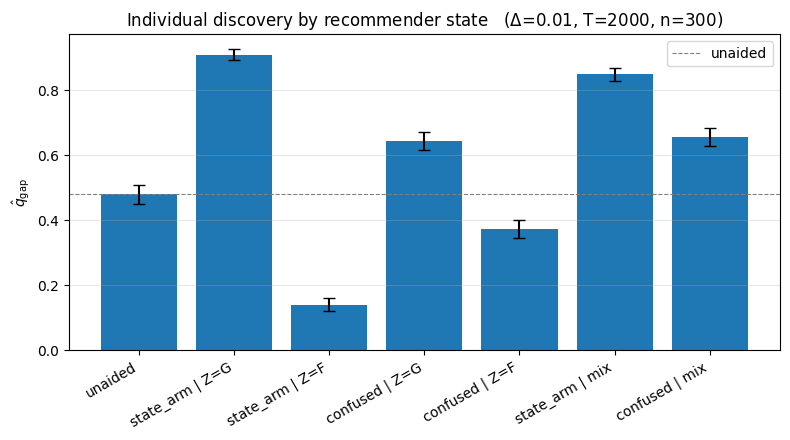

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(range(len(indiv)), indiv['q_hat'], yerr=indiv['se'], capsize=4)
ax.axhline(indiv.loc['unaided', 'q_hat'], color='grey', ls='--', lw=0.8, label='unaided')
ax.set_xticks(range(len(indiv)))
ax.set_xticklabels(indiv.index, rotation=30, ha='right')
ax.set_ylabel(r'$\hat q_{\mathrm{gap}}$')
ax.set_title(f'Individual discovery by recommender state   '
             f'($\\Delta$={GAP_HARD}, T={T_MAIN}, n={N_MAIN})')
ax.legend()
ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
indiv_fig_path = RESULTS_DIR / f'phase2_es_individual_{STAMP}.png'
fig.savefig(indiv_fig_path, dpi=150)
plt.show()

## 2. Horizon dependence of the confused variant

In the confused $F$-state the shared stream pushes *every* agent's posterior gap toward the same negative value, so $q_F \to 0$ and $q_G \to 1$ — but only once the stream's own sampling noise falls below the criterion margin. After $T$ steps each arm has received $\sim T/2$ shared draws, so the posterior means it pins fluctuate by $\sim \sqrt{1/(2T)}$; separation requires that to be small against $\delta = \Delta/2$, i.e. $T \gtrsim 1/\Delta^2$. At the operating point $\Delta = 0.01$ that is tens of thousands of steps — this section traces $\hat q(T)$ for both forced states to make the convergence (and its cost at a hard gap) visible. Each point is an independent run of $N$ agents; error bars are $\pm 1$ se.

In [6]:
%%time
rows = []
for T in tqdm(T_GRID, desc='horizon sweep'):
    for z_label, pg in (('G', 1.0), ('F', 0.0)):
        make = lambda b, pg=pg: EvidenceSharingRecommender(b, p_good=pg, variant='confused')
        mask, _ = run_cond(GAP_HARD, make, N_TRAJ, T)
        rows.append({'T': T, 'z': z_label, 'q_hat': float(mask.mean()), 'se': se_of(mask)})
horizon = pd.DataFrame(rows)
horizon.pivot(index='T', columns='z', values='q_hat')

horizon sweep:   0%|          | 0/4 [00:00<?, ?it/s]

CPU times: user 3min 7s, sys: 1.81 s, total: 3min 9s
Wall time: 3min 14s


z,F,G
T,,
1000,0.42,0.65
3000,0.33,0.61
10000,0.16,0.71
30000,0.11,0.87


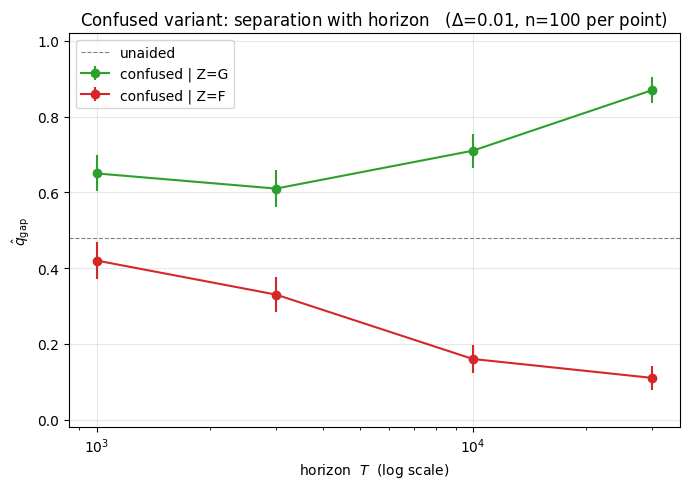

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
for z_label, color in (('G', 'tab:green'), ('F', 'tab:red')):
    grp = horizon[horizon['z'] == z_label]
    ax.errorbar(grp['T'], grp['q_hat'], yerr=grp['se'], marker='o',
                color=color, label=f'confused | Z={z_label}')
ax.axhline(indiv.loc['unaided', 'q_hat'], color='grey', ls='--', lw=0.8, label='unaided')
ax.set_xscale('log')
ax.set_xlabel('horizon  $T$  (log scale)')
ax.set_ylabel(r'$\hat q_{\mathrm{gap}}$')
ax.set_ylim(-0.02, 1.02)
ax.set_title(f'Confused variant: separation with horizon   ($\\Delta$={GAP_HARD}, n={N_TRAJ} per point)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
horizon_fig_path = RESULTS_DIR / f'phase2_es_horizon_{STAMP}.png'
fig.savefig(horizon_fig_path, dpi=150)
plt.show()

## 3. The community headline (coarse gap)

**Why switch to `GAP_EASY` $= 0.1$ here?** Two compounding costs at the paper's $\Delta = 0.01$. First, by section 2's noise argument, the confused variant needs $T \gtrsim 1/\Delta^2 \sim 10^4$–$10^5$ steps to separate at all. Second, the community headline is more demanding still: with $n = 100$ agents the community fails only when *every* agent fails, so $P(D \mid F) = 1 - (1 - q_F)^n$ stays $\approx 1$ unless $q_F$ is pushed essentially to zero (even $q_F = 0.15$ leaves $1 - 0.85^{100} \approx 1$ — individual suppression alone does not hurt the community). Driving $q_F$ below $\sim 1/n$ at $\Delta = 0.01$ would take $T \sim 5 \times 10^4$ and minutes-to-hours of compute. At $\Delta = 0.1$ the same mechanism completes by $T \approx 3000$ — $q_G \to 1$, $q_F \to 0$ — so the full effect is demonstrable at laptop cost. Nothing about the mechanism is gap-specific; the coarse gap only buys speed of separation.

**What gets computed.** Given $Z$, agents are i.i.d. (shared draws are independent per agent), so the community discovery probability is the exact closed form $P(D \mid Z) = 1 - (1 - q_Z)^n$; we verify it empirically by bootstrap-resampling communities of size $n$ from the per-agent masks. The aided community probability is $P(D) = 0.99\,P(D \mid G) + 0.01\,P(D \mid F)$, plotted against the unaided $1 - (1 - q_u)^n$ as a function of $n$. The `per_share` mixture is the control: same recommender, $Z$ re-flipped per share, errors independent across agents — community success should be restored, isolating the common-$Z$ draw as the mechanism.

In [8]:
%%time
EASY_CONDS = {
    'unaided':  None,
    'Z=G':      lambda b: EvidenceSharingRecommender(b, p_good=1.0, variant='confused'),
    'Z=F':      lambda b: EvidenceSharingRecommender(b, p_good=0.0, variant='confused'),
    'mix':      lambda b: EvidenceSharingRecommender(b, p_good=P_GOOD, z_mode='per_share', variant='confused'),
}
easy_masks = {}
for name, make in tqdm(EASY_CONDS.items(), desc='coarse-gap conditions'):
    easy_masks[name], _ = run_cond(GAP_EASY, make, N_MAIN, T_EASY)

easy = pd.DataFrame([
    {'condition': k, 'q_hat': float(m.mean()), 'se': se_of(m)} for k, m in easy_masks.items()
]).set_index('condition')
easy.round(3)

coarse-gap conditions:   0%|          | 0/4 [00:00<?, ?it/s]

CPU times: user 1min 13s, sys: 461 ms, total: 1min 13s
Wall time: 1min 15s


,q_hat,se
condition,,
unaided,0.65,0.028
Z=G,1.00,0.000
Z=F,0.00,0.000
mix,1.00,0.000


In [9]:
q_u, q_G, q_F, q_mix = (easy.loc[k, 'q_hat'] for k in ('unaided', 'Z=G', 'Z=F', 'mix'))

# Closed forms at the paper's community size.
P_D = {
    'unaided':           1 - (1 - q_u) ** N_COMM,
    'aided (community)': P_GOOD * (1 - (1 - q_G) ** N_COMM) + (1 - P_GOOD) * (1 - (1 - q_F) ** N_COMM),
    'aided (per_share)': 1 - (1 - q_mix) ** N_COMM,
}
q_aided = P_GOOD * q_G + (1 - P_GOOD) * q_F
print(f'individual:  unaided q = {q_u:.3f}   aided q = 0.99*{q_G:.3f} + 0.01*{q_F:.3f} = {q_aided:.3f}')
for k, v in P_D.items():
    print(f'community (n={N_COMM}):  {k:20} P(D) = {v:.5f}')

# Empirical check of the closed form by bootstrap communities from the masks.
rng = np.random.default_rng(MASTER_SEED)
for k, m in (('Z=G', easy_masks['Z=G']), ('Z=F', easy_masks['Z=F'])):
    boot = np.array([m[rng.integers(0, m.size, N_COMM)].any() for _ in range(4000)])
    closed = 1 - (1 - m.mean()) ** N_COMM
    print(f'bootstrap check {k}: closed form {closed:.4f}  vs  resampled {boot.mean():.4f}')

individual:  unaided q = 0.650   aided q = 0.99*1.000 + 0.01*0.000 = 0.990
community (n=100):  unaided              P(D) = 1.00000
community (n=100):  aided (community)    P(D) = 0.99000
community (n=100):  aided (per_share)    P(D) = 1.00000
bootstrap check Z=G: closed form 1.0000  vs  resampled 1.0000
bootstrap check Z=F: closed form 0.0000  vs  resampled 0.0000


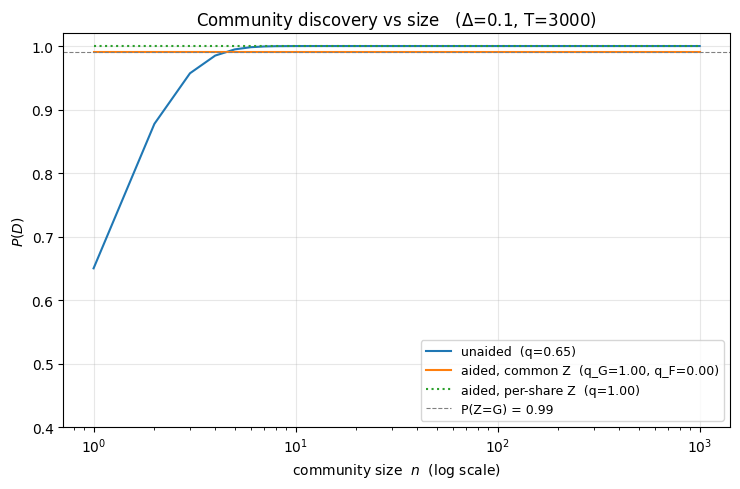

In [10]:
n_grid = np.unique(np.round(np.logspace(0, 3, 40)).astype(int))
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(n_grid, 1 - (1 - q_u) ** n_grid, label=f'unaided  (q={q_u:.2f})')
ax.plot(n_grid, P_GOOD * (1 - (1 - q_G) ** n_grid) + (1 - P_GOOD) * (1 - (1 - q_F) ** n_grid),
        label=f'aided, common Z  (q_G={q_G:.2f}, q_F={q_F:.2f})')
ax.plot(n_grid, 1 - (1 - q_mix) ** n_grid, ls=':',
        label=f'aided, per-share Z  (q={q_mix:.2f})')
ax.axhline(P_GOOD, color='grey', ls='--', lw=0.8, label=f'P(Z=G) = {P_GOOD}')
ax.set_xscale('log')
ax.set_xlabel('community size  $n$  (log scale)')
ax.set_ylabel(r'$P(D)$')
ax.set_ylim(0.4, 1.02)
ax.set_title(f'Community discovery vs size   ($\\Delta$={GAP_EASY}, T={T_EASY})')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
comm_fig_path = RESULTS_DIR / f'phase2_es_community_{STAMP}.png'
fig.savefig(comm_fig_path, dpi=150)
plt.show()

## Save

Persist all measured $\hat q$ values as one timestamped CSV under [`results/`](../results/), alongside the three figures already written by the plot cells.

In [11]:
rows = []
for cond, m in indiv_masks.items():
    rows.append({'section': 'individual', 'gap': GAP_HARD, 'T': T_MAIN, 'n_agents': N_MAIN,
                 'condition': cond, 'q_hat': float(m.mean()), 'se': se_of(m)})
for _, r in horizon.iterrows():
    rows.append({'section': 'horizon', 'gap': GAP_HARD, 'T': int(r['T']), 'n_agents': N_TRAJ,
                 'condition': f"confused | Z={r['z']}", 'q_hat': r['q_hat'], 'se': r['se']})
for cond, m in easy_masks.items():
    rows.append({'section': 'community', 'gap': GAP_EASY, 'T': T_EASY, 'n_agents': N_MAIN,
                 'condition': cond, 'q_hat': float(m.mean()), 'se': se_of(m)})
out = pd.DataFrame(rows)
csv_path = RESULTS_DIR / f'phase2_es_q_{STAMP}.csv'
out.to_csv(csv_path, index=False)
print(f'q table        -> {csv_path.relative_to(PAPER_ROOT)}')
print(f'individual fig -> {indiv_fig_path.relative_to(PAPER_ROOT)}')
print(f'horizon fig    -> {horizon_fig_path.relative_to(PAPER_ROOT)}')
print(f'community fig  -> {comm_fig_path.relative_to(PAPER_ROOT)}')

q table        -> results/phase2_es_q_20260610_174604.csv
individual fig -> results/phase2_es_individual_20260610_174604.png
horizon fig    -> results/phase2_es_horizon_20260610_174604.png
community fig  -> results/phase2_es_community_20260610_174604.png


## What this shows

- **Both states of both variants move individual discovery as designed** (section 1, $\Delta = 0.01$, $T = 2000$): from the unaided $\hat q = 0.48$, the honest `state_arm` variant gives $q_G = 0.91$ and $q_F = 0.14$ — even a failure state that only ever shares *true* data about the worse arm cuts individual discovery to a third of baseline, via the comparison race described above. The `confused` variant reads $0.64 / 0.37$ at this short horizon — only partially separated, as expected at a hard gap.
- **The confused variant's separation is horizon-limited, as the noise argument predicts** (section 2): $q_G$ climbs $0.65 \to 0.87$ and $q_F$ falls $0.42 \to 0.11$ as $T$ goes $10^3 \to 3 \times 10^4$, heading for $1$ and $0$ but visibly incomplete even at $T = 30000$ — at $\Delta = 0.01$ full separation needs $T \sim 10^5$. This is purely a speed issue, which is why section 3 demonstrates the endpoint at a coarser gap.
- **The community headline lands, exactly** (section 3, $\Delta = 0.1$, $T = 3000$, where separation is complete: $q_G = 1.000$, $q_F = 0.000$, unaided $q_u = 0.650$):
  - *Individuals improve*: aided $q = 0.99 \times 1.000 + 0.01 \times 0.000 = 0.990 \gg 0.650$.
  - *The community gets worse*: unaided $P(D) = 1.00000$; aided with a common $Z$, $P(D) = 0.99000$ — the community now fails exactly when the shared recommender is in its failure state, and the $0.01$ failure mass cannot be diversified away by adding agents (the $P(D)$-vs-$n$ curve plateaus at $P(Z{=}G) = 0.99$).
  - *The control isolates the mechanism*: the `per_share` recommender — identical marginal data stream, $Z$ re-flipped per share so errors are independent — restores $P(D) = 1.00000$. The harm is entirely attributable to the commonness of $Z$, not to the recommender's error rate.
- **Individual suppression alone is not community harm.** The honest `state_arm` failure state, despite cutting $q$ to $0.14$, leaves $P(D \mid F) = 1 - 0.86^{100} \approx 1$: a hundred independent gambles still virtually guarantee one winner. Community failure requires the failure state to push *every* agent's beliefs the same wrong way — corrupted common evidence (the confused variant), not merely biased sampling. This sharpens §3–§5 of the paper: the conjectured $P(D_i \mid F) \approx 0$ is not a free parameter choice but a structural requirement on what the failure state does.
- **Bootstrap checks confirm the closed forms** ($P(D \mid Z) = 1 - (1-q_Z)^n$ matches resampled communities to 4 decimals), as they must under conditional independence given $Z$.